# MOTIVATION: There are currently two less-than-ideal problems with the NIHPD phantom. This notebook is exploring them and possible fixes.

### Problem 1:
Our NIHPD skull is too thick. Currently, we're assigning one HU value to all materials outside of the brain. This includes fat, eyes, and other non-skull tissues that have much lower HU. Thus the simulated photons are passing through much more high attenuating material leading to artifacts. Possible solutions:
1. Find new threshold values for either PDw, T1w, or T2w images
2. Create a pseudo CT image to easier segment bones and use as skull mask 

### Problem 2:
Due to atlas/template construction in MNI space, NIHPD images are larger than expected. I'm attempting two possible solutions (may be in a different notebook):
1. A simple scale transform to decrease brain volume to be equal to values in the literature. (Will correct overall volume, but not shape)
2. [Warp the NIHPD atlases to an age-appropriate T1w MRI subject](https://github.com/DIDSR/InSilicoICH/issues/36) (Should correct overall volume and shape, but details may be lost in warp).

In [1]:
from insilicoICH.ground_truth_definition.phantoms import load_phantom
age = 6.5
phantom = load_phantom(age)

temp_mida = load_phantom(age=38)
mida_image = temp_mida.get_CT_number_phantom()

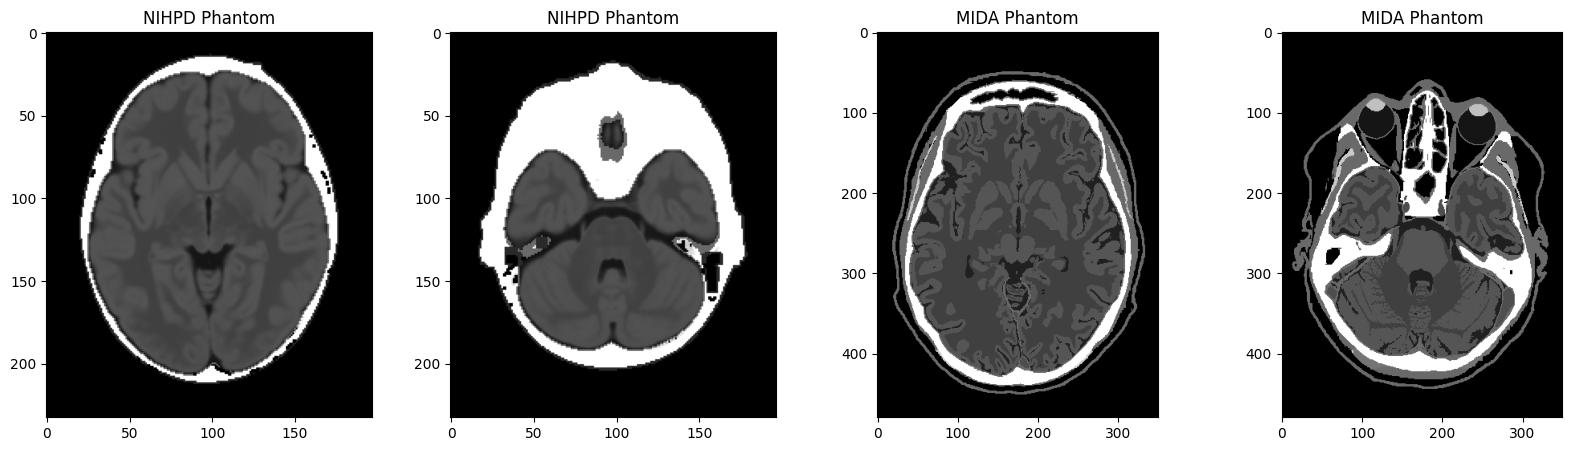

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axs= plt.subplots(1, 4, figsize=(20,5))
axs[0].set_title('NIHPD Phantom')
axs[0].imshow(phantom._phantom[120, :, :], cmap='gray', vmin=0, vmax=120)
axs[1].set_title('NIHPD Phantom')
axs[1].imshow(phantom._phantom[150, :, :], cmap='gray', vmin=0, vmax=120)

axs[2].set_title('MIDA Phantom')
axs[2].imshow(mida_image[200, :, :], cmap='gray', vmin=0, vmax=120)
axs[3].set_title('MIDA Phantom')
axs[3].imshow(mida_image[250, :, :], cmap='gray', vmin=0, vmax=120)
plt.show()

Look at all those high HU voxels!

Let's start by loading the NIHPD from scratch and apply some of the same functions found within the source code.

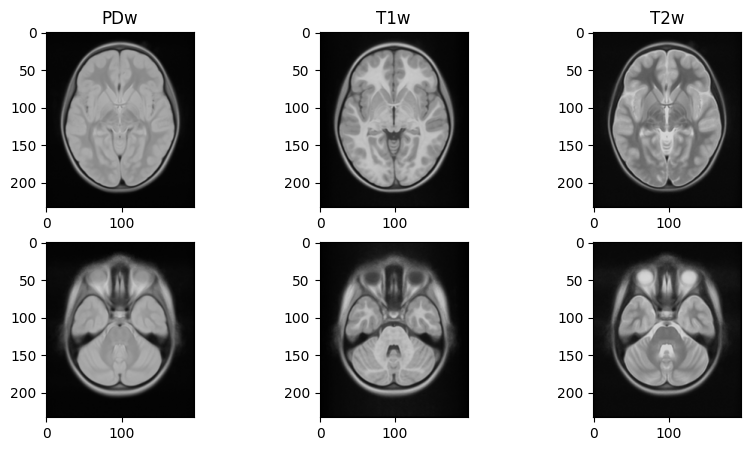

Skull mask in the code - everything outside of the brain is considered skull


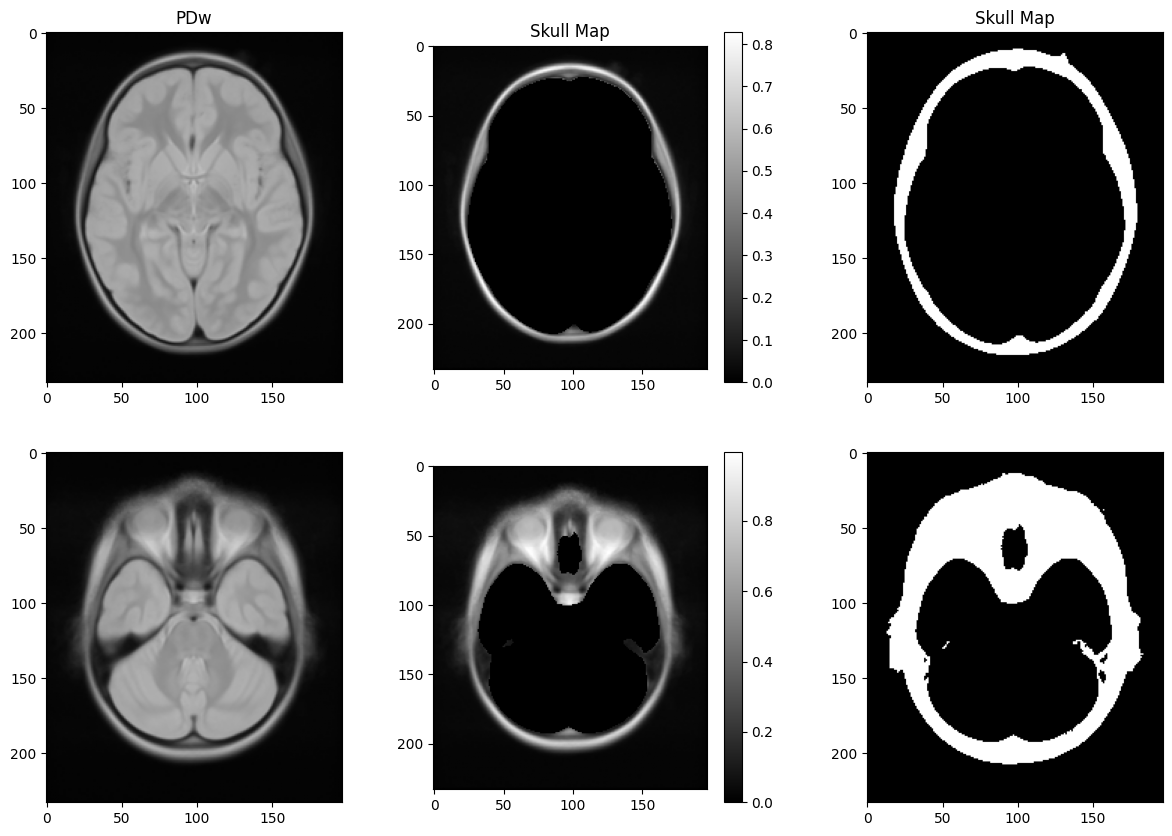

In [3]:
import numpy as np
import nibabel as nib
from pathlib import Path

base_dir=Path('/home/jayse.weaver/repositories/InSilicoICH/phantoms/NIHPD_Head_Phantom')
symmetry='asym'
age_range='04.5-08.5'
csf = nib.load(base_dir / f'nihpd_{symmetry}_{age_range}_csf.nii').get_fdata().transpose(2, 1, 0)[::-1, ::-1, :]
gm = nib.load(base_dir / f'nihpd_{symmetry}_{age_range}_gm.nii').get_fdata().transpose(2, 1, 0)[::-1, ::-1, :]
wm = nib.load(base_dir / f'nihpd_{symmetry}_{age_range}_wm.nii').get_fdata().transpose(2, 1, 0)[::-1, ::-1, :]
mask = nib.load(base_dir / f'nihpd_{symmetry}_{age_range}_mask.nii').get_fdata().transpose(2, 1, 0)[::-1, ::-1, :]
pdw = nib.load(base_dir / f'nihpd_{symmetry}_{age_range}_pdw.nii').get_fdata().transpose(2, 1, 0)[::-1, ::-1, :]
t1w = nib.load(base_dir / f'nihpd_{symmetry}_{age_range}_t1w.nii').get_fdata().transpose(2, 1, 0)[::-1, ::-1, :]
t2w = nib.load(base_dir / f'nihpd_{symmetry}_{age_range}_t2w.nii').get_fdata().transpose(2, 1, 0)[::-1, ::-1, :]


fig, axs= plt.subplots(2, 3, figsize=(10,5))
axs[0, 0].set_title('PDw')
axs[0, 0].imshow(pdw[120, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 0].imshow(pdw[150, :, :], cmap='gray', vmin=0, vmax=120)

axs[0, 1].set_title('T1w')
axs[0, 1].imshow(t1w[120, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 1].imshow(t1w[150, :, :], cmap='gray', vmin=0, vmax=120)

axs[0, 2].set_title('T2w')
axs[0, 2].imshow(t2w[120, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 2].imshow(t2w[150, :, :], cmap='gray', vmin=0, vmax=120)
plt.show()

print('Skull mask in the code - everything outside of the brain is considered skull')

# get skull mask code, as it's used in src/insilicoICH/ground_truth_definition/phantoms.py:
'''obtains rudimentary mask of skull voxels using threshold of
proton-density weighted image and full mask'''
skull_map = (mask == 0)*pdw / pdw.max()

fig, axs= plt.subplots(2, 3, figsize=(15,10))
axs[0, 0].set_title('PDw')
axs[0, 0].imshow(pdw[120, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 0].imshow(pdw[150, :, :], cmap='gray', vmin=0, vmax=120)

axs[0, 1].set_title('Skull Map')
img = axs[0, 1].imshow(skull_map[120, :, :], cmap='gray')
fig.colorbar(img, ax=axs[0, 1])
img = axs[1, 1].imshow(skull_map[150, :, :], cmap='gray')
fig.colorbar(img, ax=axs[1, 1])

# make final binarized skull map
skull_map[skull_map < 0.1] = 0
skull_map[skull_map > 0] = 1

axs[0, 2].set_title('Skull Map')
axs[0, 2].imshow(skull_map[120, :, :], cmap='gray')
axs[1, 2].imshow(skull_map[150, :, :], cmap='gray')
plt.show()


## Above implementation is an error - we now need a more elegant way to find the skull

### Below shows an attempt to find a new skull mask with a lower and upper threshold
There are two problems here:
1. The 'ring' of the skull is broken in parts due to varying intensities of the skull
2. An additional non-skull 'ring' is created where the background meets the tissue of the head (fat, skin etc)

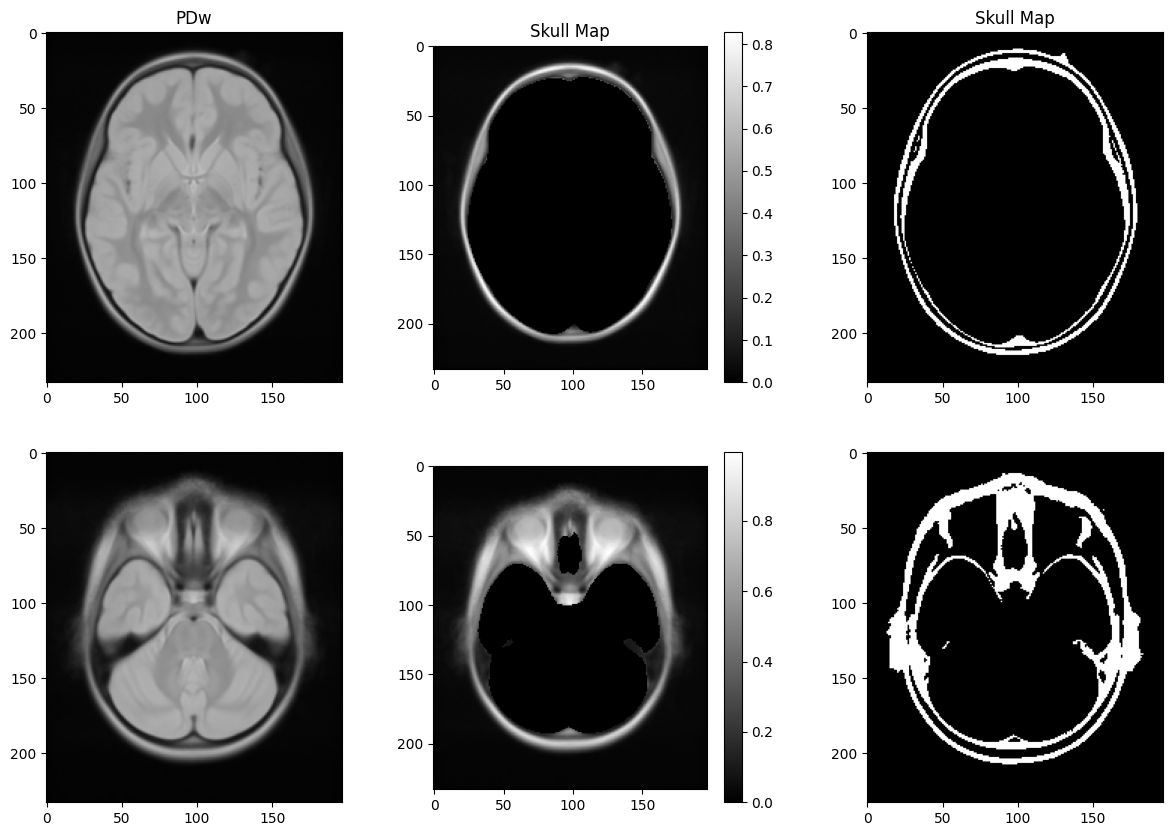

In [4]:
skull_map = (mask == 0)*pdw / pdw.max()

fig, axs= plt.subplots(2, 3, figsize=(15,10))
axs[0, 0].set_title('PDw')
axs[0, 0].imshow(pdw[120, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 0].imshow(pdw[150, :, :], cmap='gray', vmin=0, vmax=120)

axs[0, 1].set_title('Skull Map')
img = axs[0, 1].imshow(skull_map[120, :, :], cmap='gray')
fig.colorbar(img, ax=axs[0, 1])
img = axs[1, 1].imshow(skull_map[150, :, :], cmap='gray')
fig.colorbar(img, ax=axs[1, 1])

# make final binarized skull map
# skull_map[skull_map < 0.1] = 1
# skull_map[skull_map < 1] = 0

skull_mask = np.where(np.logical_and(skull_map>0.1, skull_map<=0.5), 1, 0)

axs[0, 2].set_title('Skull Map')
axs[0, 2].imshow(skull_mask[120, :, :], cmap='gray')
axs[1, 2].imshow(skull_mask[150, :, :], cmap='gray')
plt.show()

### Also looking into possibilities segmenting a thresholded mask, but the background is typically 'connected' to the skull due to similar intensity.

Segmenting just the background noise out may be beneficial - nonuniform background noise makes thresholding more difficult.



interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

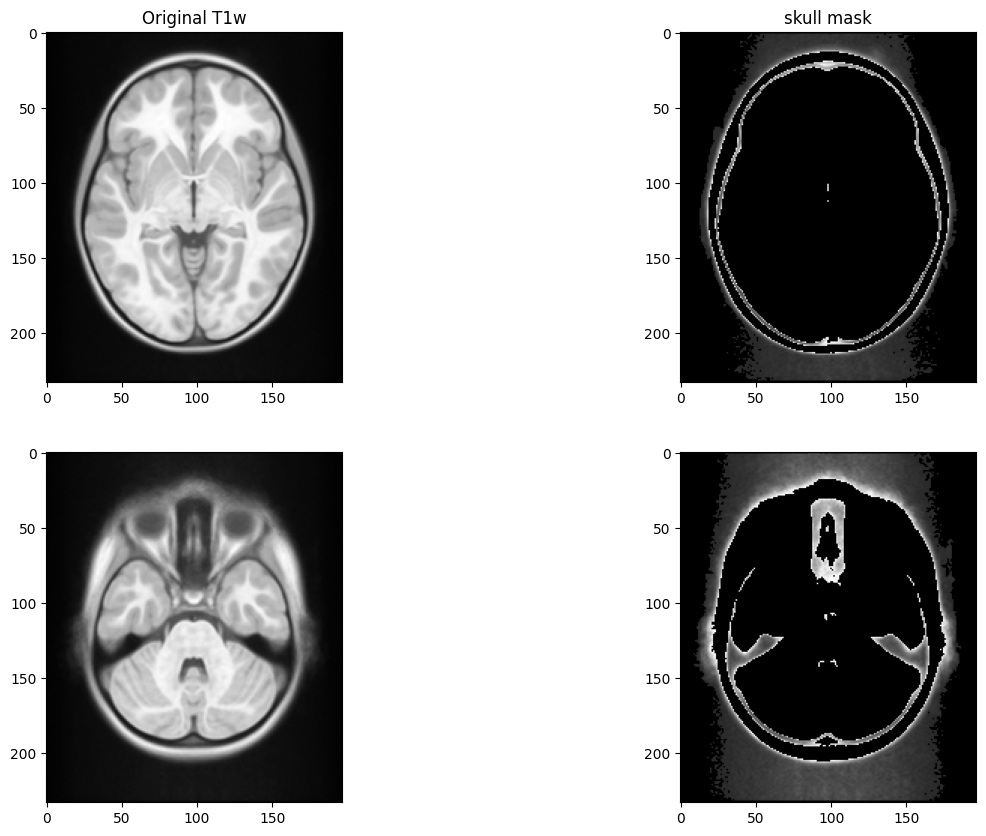

In [ ]:
import numpy as np
from utils import scrollview
import skimage as ski

from mpl_toolkits.axes_grid1 import make_axes_locatable

# attempt to threshold T1w image:
upper_threshold = -15000*0.0015546214 + 50.941822
lower_threshold = -30000*0.0015546214 + 50.941822
bkg_threshold = -28000 # ?

skull_mask = np.copy(t1w)
skull_mask = np.where(t1w > upper_threshold, 0, t1w)
skull_mask = np.where(skull_mask < lower_threshold, 0, t1w)
#skull_mask = np.where(skull_mask != 0, 1, 0)


scrollview(skull_mask, display=(1,0))

fig, axs= plt.subplots(2, 2, figsize=(15,10))
axs[0, 0].set_title('Original T1w')
axs[0, 0].imshow(t1w[120, :, :], cmap='gray')
axs[1, 0].imshow(t1w[150, :, :], cmap='gray')

axs[0, 1].set_title('skull mask')
axs[0, 1].imshow(skull_mask[120, :, :], cmap='gray')
axs[1, 1].imshow(skull_mask[150, :, :], cmap='gray')

plt.show()


### Alternatives: Use a pseudo CT generator to get skull mask

Currently in a separate repository: (didsr-wk46-050fdagov) /home/jayse.weaver/repositories/mr-to-pct

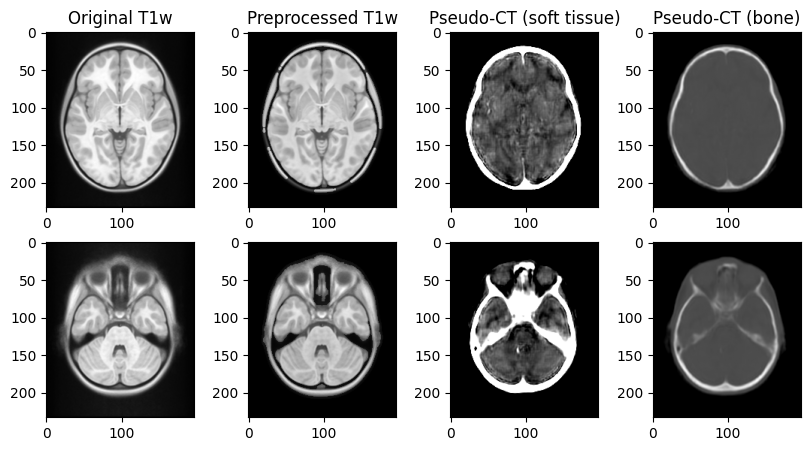

In [13]:
pCT_path = '/home/jayse.weaver/repositories/mr-to-pct/'

# read original t1w
t1w_orig = nib.load(pCT_path + 'nihpd_asym_04.5-08.5_t1w.nii').get_fdata().transpose(2, 1, 0)[::-1, ::-1, :]

# read mr-to-pct output
t1w_prep = nib.load(pCT_path + 'nihpd_asym_04.5-08.5_t1w_prep.nii').get_fdata().transpose(2, 1, 0)[::-1, ::-1, :]
pct = nib.load(pCT_path + 'nihpd_asym_04.5-08.5_pct.nii').get_fdata().transpose(2, 1, 0)[::-1, ::-1, :]

fig, axs= plt.subplots(2, 4, figsize=(10,5))
axs[0, 0].set_title('Original T1w')
axs[0, 0].imshow(t1w_orig[120, :, :], cmap='gray')
axs[1, 0].imshow(t1w_orig[150, :, :], cmap='gray')

axs[0, 1].set_title('Preprocessed T1w')
axs[0, 1].imshow(t1w_prep[120, :, :], cmap='gray')
axs[1, 1].imshow(t1w_prep[150, :, :], cmap='gray')

axs[0, 2].set_title('Pseudo-CT (soft tissue)')
axs[0, 2].imshow(pct[120, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 2].imshow(pct[150, :, :], cmap='gray', vmin=0, vmax=120)

axs[0, 3].set_title('Pseudo-CT (bone)')
axs[0, 3].imshow(pct[120, :, :], cmap='gray', vmin=-800, vmax=2000)
axs[1, 3].imshow(pct[150, :, :], cmap='gray', vmin=-800, vmax=2000)
plt.show()

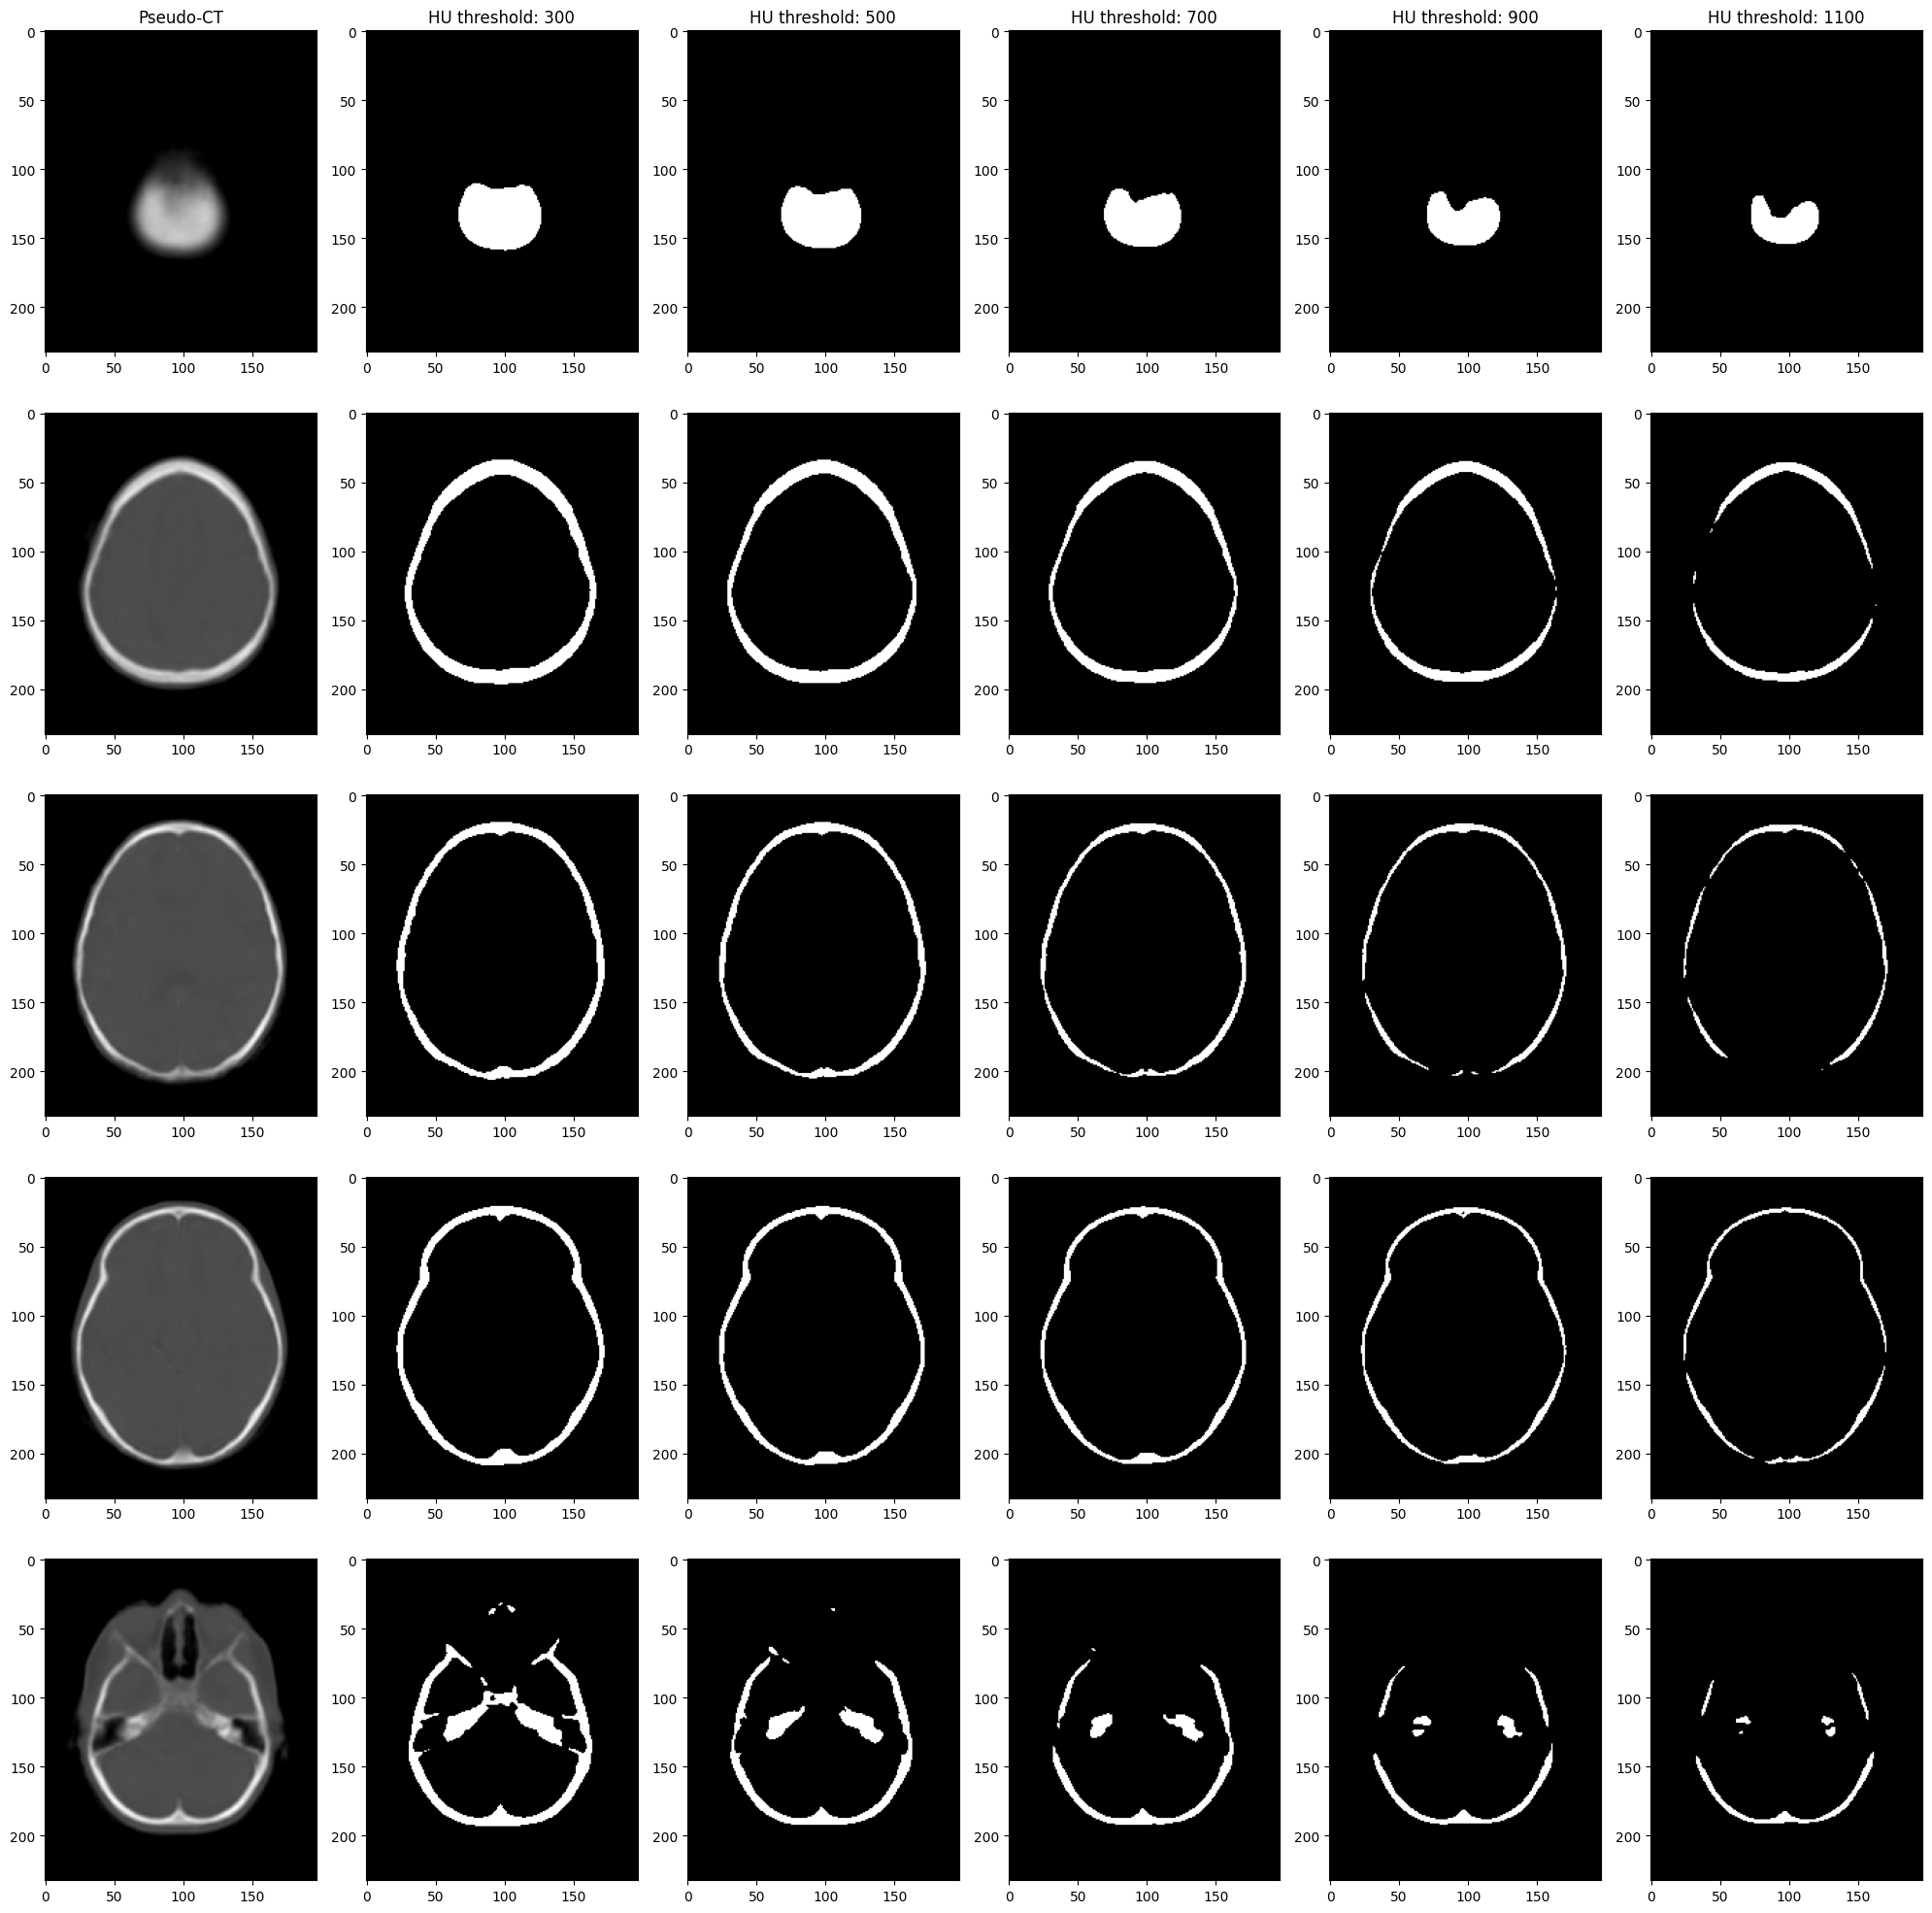

In [25]:
thresholds = [0, 300, 500, 700, 900, 1100]

fig, axs= plt.subplots(5, len(thresholds), figsize=(20,20))
for idx, threshold in enumerate(thresholds):

    if idx==0:
        axs[0, idx].set_title('Pseudo-CT')
        axs[0, idx].imshow(pct[30, :, :], cmap='gray', vmin=-800, vmax=2000)
        axs[1, idx].imshow(pct[70, :, :], cmap='gray', vmin=-800, vmax=2000)
        axs[2, idx].imshow(pct[100, :, :], cmap='gray', vmin=-800, vmax=2000)
        axs[3, idx].imshow(pct[130, :, :], cmap='gray', vmin=-800, vmax=2000)
        axs[4, idx].imshow(pct[160, :, :], cmap='gray', vmin=-800, vmax=2000)
    else:
        skull_mask = np.where(pct > threshold, 1, 0)
        axs[0, idx].set_title('HU threshold: ' + str(threshold))
        axs[0, idx].imshow(skull_mask[30, :, :], cmap='gray')
        axs[1, idx].imshow(skull_mask[70, :, :], cmap='gray')
        axs[2, idx].imshow(skull_mask[100, :, :], cmap='gray')
        axs[3, idx].imshow(skull_mask[130, :, :], cmap='gray')
        axs[4, idx].imshow(skull_mask[160, :, :], cmap='gray')

plt.tight_layout()
plt.show()

### Construct a new NIHPD phantom:
* The old WM/GM/CSF masks
* The new skull mask (from pseudo-CT)
* The extra-cranial HU (from pseudo-CT)

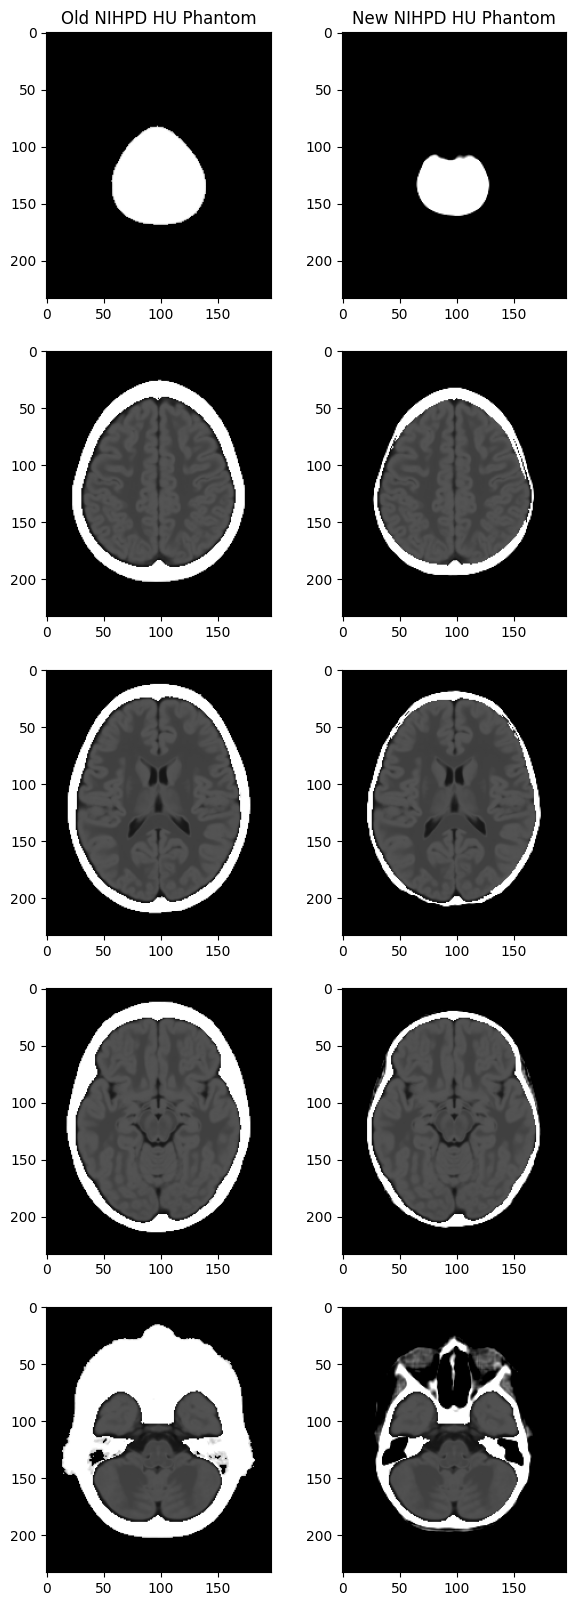

In [29]:
old_NIHPD = phantom.csf*phantom.csf_HU + phantom.gm*phantom.gm_HU + phantom.wm*phantom.wm_HU + phantom.skull*phantom.skull_HU

new_NIHPD = pct*((mask-1)*-1) + phantom.csf*phantom.csf_HU + phantom.gm*phantom.gm_HU + phantom.wm*phantom.wm_HU + skull_mask*phantom.skull_HU

fig, axs= plt.subplots(5, 2, figsize=(7,20))

axs[0, 0].set_title('Old NIHPD HU Phantom')
axs[0, 0].imshow(old_NIHPD[30, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 0].imshow(old_NIHPD[70, :, :], cmap='gray', vmin=0, vmax=120)
axs[2, 0].imshow(old_NIHPD[100, :, :], cmap='gray', vmin=0, vmax=120)
axs[3, 0].imshow(old_NIHPD[130, :, :], cmap='gray', vmin=0, vmax=120)
axs[4, 0].imshow(old_NIHPD[160, :, :], cmap='gray', vmin=0, vmax=120)

skull_mask = np.where(pct > threshold, 1, 0)
axs[0, 1].set_title('New NIHPD HU Phantom')
axs[0, 1].imshow(new_NIHPD[30, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 1].imshow(new_NIHPD[70, :, :], cmap='gray', vmin=0, vmax=120)
axs[2, 1].imshow(new_NIHPD[100, :, :], cmap='gray', vmin=0, vmax=120)
axs[3, 1].imshow(new_NIHPD[130, :, :], cmap='gray', vmin=0, vmax=120)
axs[4, 1].imshow(new_NIHPD[160, :, :], cmap='gray', vmin=0, vmax=120)

### Still todo: create better background mask (should be ALL -1000)

Justification for manuscript: "combine the soft tissue resolution of MRI with superior bone visualization of CT..."

Since we're only doing this workflow for the NIHPD phantoms, we can just check pseudo-CT output once - we're not relying on pseudo-CT to be completely accurate everywhere since we're re-assigning HU anyway.